<a href="https://colab.research.google.com/github/gallegoshernandezcarlosmihael01/MAA_Practicas_3_4_5/blob/main/Pr%C3%A1ctica_5_M%C3%A1quinas_de_vectores_de_soporte_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 5. Máquinas de vectores de soporte (SVM)**

Gallegos Hernández Carlos Mihael , López Castillejos Aseret Laxhidua

# **Paso 1. Importar las bibliotecas**

In [1]:
# Importar NumPy para operaciones numéricas.
import numpy as np


In [2]:
# Importar Pandas para organizar los datos en tablas.
import pandas as pd


In [3]:
# Importar Matplotlib para construir gráficas.
import matplotlib.pyplot as plt

In [4]:
# Importar el conjunto de datos de tumores de mama.
from sklearn.datasets import load_breast_cancer

In [5]:
# Importar la función para dividir los datos.
from sklearn.model_selection import train_test_split

In [6]:
# Importar StandardScaler para estandarizar las características.
from sklearn.preprocessing import StandardScaler

In [7]:
# Importar Pipeline para encadenar el escalado y el clasificador.
from sklearn.pipeline import Pipeline

In [8]:
# Importar el clasificador de máquinas de vectores de soporte.
from sklearn.svm import SVC

In [9]:
# Importar métricas para evaluar la clasificación.
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 confusion_matrix,
 classification_report,
 roc_auc_score,
 ConfusionMatrixDisplay,
 RocCurveDisplay
)

# **Paso 2. Cargar el conjunto de datos**

In [10]:
# Cargar los datos desde el módulo de conjuntos de datos de Scikit-learn.
datos = load_breast_cancer()


In [11]:
# Convertir las características en una tabla de Pandas.
X = pd.DataFrame(
 datos.data,
 columns=datos.feature_names
)


In [14]:
# Convertir las etiquetas en una serie de Pandas.
y = pd.Series(
 datos.target,
 name="diagnostico"
)

In [12]:
# Mostrar las primeras cinco observaciones.
display(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
# Mostrar las primeras cinco etiquetas.
display(y.head())

,diagnostico
0,0
1,0
2,0
3,0
4,0


# **Paso 3. Consultar las dimensiones, las etiquetas y los valores faltantes**

In [16]:
# Mostrar el número de observaciones y características.
print("Dimensiones de X:", X.shape)

Dimensiones de X: (569, 30)


In [17]:
# Mostrar la cantidad de etiquetas disponibles.
print("Cantidad de etiquetas:", y.shape[0])

Cantidad de etiquetas: 569


In [18]:
# Mostrar las clases originales y sus códigos.
print("Clases:", datos.target_names)


Clases: ['malignant' 'benign']


In [19]:
# Contar las observaciones de cada clase.
print("Distribución de las clases:")
print(y.value_counts().sort_index())

Distribución de las clases:
diagnostico
0    212
1    357
Name: count, dtype: int64


In [20]:
# Calcular el porcentaje de observaciones por clase.
print("Porcentaje por clase:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Porcentaje por clase:
diagnostico
0    37.26
1    62.74
Name: proportion, dtype: float64


In [21]:
# Contar los valores faltantes por característica.
print("Valores faltantes por característica:")
print(X.isnull().sum().sum())


Valores faltantes por característica:
0


# **Paso 4. Crear una gráfica de frecuencias**

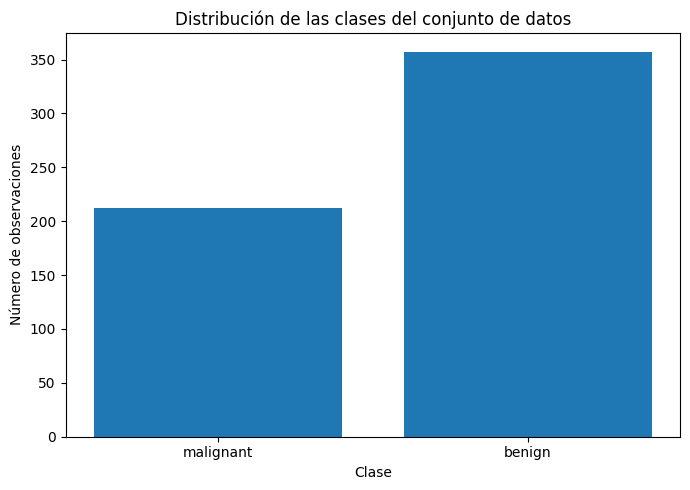

In [22]:
# Contar las observaciones de cada clase.
frecuencias = y.value_counts().sort_index()
# Crear las etiquetas legibles para la gráfica.
nombres_clases = [
 datos.target_names[0],
 datos.target_names[1]
]
# Crear una figura para la gráfica.
plt.figure(figsize=(7, 5))
# Dibujar las barras con las frecuencias de cada clase.
plt.bar(nombres_clases, frecuencias.values)
# Agregar el título de la gráfica.
plt.title("Distribución de las clases del conjunto de datos")
# Etiquetar el eje horizontal.
plt.xlabel("Clase")
# Etiquetar el eje vertical.
plt.ylabel("Número de observaciones")
# Ajustar los elementos de la figura.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()

# **Paso 5. Separar entrenamiento y prueba**

In [23]:
# Dividir las características y las etiquetas en dos conjuntos.
# El 80 % se utilizará para entrenar y el 20 % para probar.
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=42,
 stratify=y
)

In [24]:
# Mostrar el tamaño del conjunto de entrenamiento.
print("Observaciones de entrenamiento:", X_train.shape[0])

Observaciones de entrenamiento: 455


In [25]:
# Mostrar el tamaño del conjunto de prueba.
print("Observaciones de prueba:", X_test.shape[0])

Observaciones de prueba: 114


In [26]:
# Comprobar la distribución de clases en entrenamiento.
print("Clases en entrenamiento:")
print(y_train.value_counts().sort_index())


Clases en entrenamiento:
diagnostico
0    170
1    285
Name: count, dtype: int64


In [27]:
# Comprobar la distribución de clases en prueba.
print("Clases en prueba:")
print(y_test.value_counts().sort_index())

Clases en prueba:
diagnostico
0    42
1    72
Name: count, dtype: int64


# **Paso 6. Construir y entrenar el clasificador**

In [28]:
# Crear una secuencia de procesamiento para el clasificador.
modelo_lineal = Pipeline([
 # Estandarizar las características usando solo X_train.
 ("escalado", StandardScaler()),
 # Crear un SVM con frontera de decisión lineal.
 # C controla el compromiso entre margen y errores de entrenamiento.
 # probability=True habilita estimaciones de probabilidad,
 # aunque requiere un ajuste adicional durante el entrenamiento.
 ("clasificador", SVC(
 kernel="linear",
 C=1.0,
 probability=True,
 random_state=42
 ))
])



In [30]:
# Ajustar el escalador y entrenar el clasificador.
modelo_lineal.fit(X_train, y_train)
# Mostrar un mensaje para confirmar que la ejecución terminó.
print("Modelo SVM lineal entrenado.")


Modelo SVM lineal entrenado.


# **Paso 7. Generar las predicciones**

In [31]:
# Predecir las clases del conjunto de prueba.
pred_lineal = modelo_lineal.predict(X_test)


In [32]:
# Mostrar las primeras diez etiquetas reales.
print("Etiquetas reales:")
print(y_test.iloc[:10].to_list())

Etiquetas reales:
[0, 1, 0, 1, 0, 1, 1, 0, 0, 0]


In [33]:
# Mostrar las primeras diez etiquetas predichas.
print("Etiquetas predichas:")
print(pred_lineal[:10])

Etiquetas predichas:
[0 1 0 0 0 1 1 0 0 0]


# **Paso 8. Calcular las métricas de clasificación**

In [34]:
# Calcular la proporción total de predicciones correctas.
accuracy_lineal = accuracy_score(y_test, pred_lineal)

In [35]:
# Calcular la precisión para la clase 0, que representa maligno.
precision_lineal = precision_score(
 y_test,
 pred_lineal,
 pos_label=0,
 zero_division=0
)

In [36]:
# Calcular la sensibilidad para la clase 0, que representa maligno.
recall_lineal = recall_score(
 y_test,
 pred_lineal,
 pos_label=0,
 zero_division=0
)


In [37]:
# Calcular el F1-score para la clase 0, que representa maligno.
f1_lineal = f1_score(
 y_test,
 pred_lineal,
 pos_label=0,
 zero_division=0
)

In [38]:
# Mostrar los resultados con cuatro decimales.
print(f"Accuracy: {accuracy_lineal:.4f}")
print(f"Precisión para maligno: {precision_lineal:.4f}")
print(f"Sensibilidad para maligno: {recall_lineal:.4f}")
print(f"F1-score para maligno: {f1_lineal:.4f}")

Accuracy: 0.9737
Precisión para maligno: 0.9535
Sensibilidad para maligno: 0.9762
F1-score para maligno: 0.9647


# **Paso 9. Visualizar los aciertos y errores**

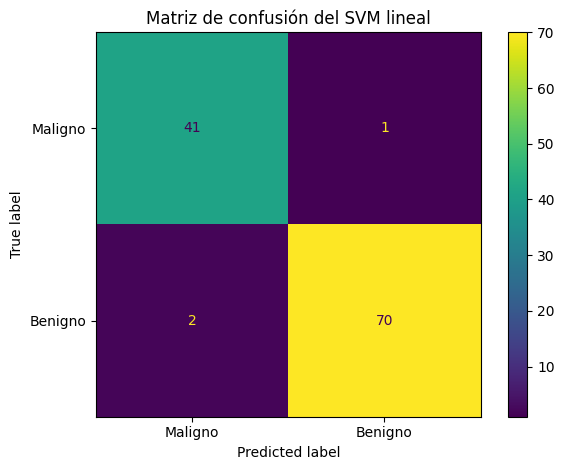

In [39]:
# Calcular la matriz de confusión.
matriz = confusion_matrix(
 y_test,
 pred_lineal,
 labels=[0, 1]
)
# Crear la visualización de la matriz de confusión.
visualizador = ConfusionMatrixDisplay(
 confusion_matrix=matriz,
 display_labels=["Maligno", "Benigno"]
)
# Dibujar la matriz con sus etiquetas.
visualizador.plot()
# Agregar el título de la gráfica.
plt.title("Matriz de confusión del SVM lineal")
# Ajustar el diseño.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()

# **Paso 10. Consultar el reporte de clasificación**

In [40]:
# Generar un reporte con precisión, sensibilidad y F1-score por clase.
reporte_lineal = classification_report(
 y_test,
 pred_lineal,
 labels=[0, 1],
 target_names=["Maligno", "Benigno"],
 zero_division=0
)
# Mostrar el reporte completo.
print(reporte_lineal)

              precision    recall  f1-score   support

     Maligno       0.95      0.98      0.96        42
     Benigno       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# **Paso 11. Entrenar un modelo con kernel RBF**

In [41]:
# Crear un pipeline para el clasificador con kernel RBF.
modelo_rbf = Pipeline([
 # Estandarizar las características de entrada.
 ("escalado", StandardScaler()),
 # Configurar el SVM con una frontera potencialmente no lineal.
 # C controla la penalización de los errores.
 # gamma controla el alcance de la influencia de las observaciones.
 ("clasificador", SVC(
 kernel="rbf",
 C=1.0,
 gamma="scale",
 probability=True,
 random_state=42
 ))
])

In [42]:
# Entrenar el modelo RBF con los datos de entrenamiento.
modelo_rbf.fit(X_train, y_train)
# Predecir las etiquetas del conjunto de prueba.
pred_rbf = modelo_rbf.predict(X_test)
# Mostrar un mensaje para identificar el modelo entrenado.
print("Modelo SVM con kernel RBF entrenado.")

Modelo SVM con kernel RBF entrenado.


# **Paso 12. Comparar las métricas de ambos modelos**

In [43]:
# Calcular las métricas del modelo lineal.
metricas_lineal = {
 "Modelo": "SVM lineal",
 "Accuracy": accuracy_score(y_test, pred_lineal),
 "Precisión maligno": precision_score(
 y_test, pred_lineal, pos_label=0, zero_division=0
 ),
 "Sensibilidad maligno": recall_score(
 y_test, pred_lineal, pos_label=0, zero_division=0
 ),
 "F1 maligno": f1_score(
 y_test, pred_lineal, pos_label=0, zero_division=0
 )
}

In [44]:
# Calcular las métricas del modelo RBF.
metricas_rbf = {
 "Modelo": "SVM RBF",
 "Accuracy": accuracy_score(y_test, pred_rbf),
 "Precisión maligno": precision_score(
 y_test, pred_rbf, pos_label=0, zero_division=0
 ),
 "Sensibilidad maligno": recall_score(
 y_test, pred_rbf, pos_label=0, zero_division=0
 ),
 "F1 maligno": f1_score(
 y_test, pred_rbf, pos_label=0, zero_division=0
 )
}

In [45]:
# Organizar las métricas en una tabla comparativa.
tabla_comparacion = pd.DataFrame([
 metricas_lineal,
 metricas_rbf
])
# Mostrar la tabla redondeada a cuatro decimales.
display(tabla_comparacion.round(4))

,Modelo,Accuracy,Precisión maligno,Sensibilidad maligno,F1 maligno
0,SVM lineal,0.9737,0.9535,0.9762,0.9647
1,SVM RBF,0.9825,0.9762,0.9762,0.9762


# **Paso 13. Calcular el ROC-AUC para la clase maligna**

In [46]:
# Obtener las probabilidades estimadas para cada clase del modelo lineal.
prob_lineal = modelo_lineal.predict_proba(X_test)

In [47]:
# Obtener las probabilidades estimadas para cada clase del modelo RBF.
prob_rbf = modelo_rbf.predict_proba(X_test)

In [51]:
# Identificar la posición de la clase maligna en el orden de clases del modelo.
indice_maligno_lineal = list(
 modelo_lineal.named_steps["clasificador"].classes_
).index(0)
# Identificar la posición de la clase maligna en el modelo RBF.
indice_maligno_rbf = list(
 modelo_rbf.named_steps["clasificador"].classes_
).index(0)
# Extraer las probabilidades de pertenecer a la clase maligna.
prob_maligno_lineal = prob_lineal[:, indice_maligno_lineal]
prob_maligno_rbf = prob_rbf[:, indice_maligno_rbf]
# Construir una etiqueta binaria: 1 para maligno y 0 para benigno.
y_test_maligno = (y_test == 0).astype(int)
# Calcular ROC-AUC para las probabilidades de la clase maligna.
auc_lineal = roc_auc_score(
 y_test_maligno,
 prob_maligno_lineal
)
# Calcular ROC-AUC del modelo RBF.
auc_rbf = roc_auc_score(
 y_test_maligno,
 prob_maligno_rbf
)
# Mostrar ambos resultados.
print(f"ROC-AUC SVM lineal: {auc_lineal:.4f}")
print(f"ROC-AUC SVM RBF: {auc_rbf:.4f}")

ROC-AUC SVM lineal: 0.9964
ROC-AUC SVM RBF: 0.9950


# **Paso 14. Visualizar las curvas ROC**

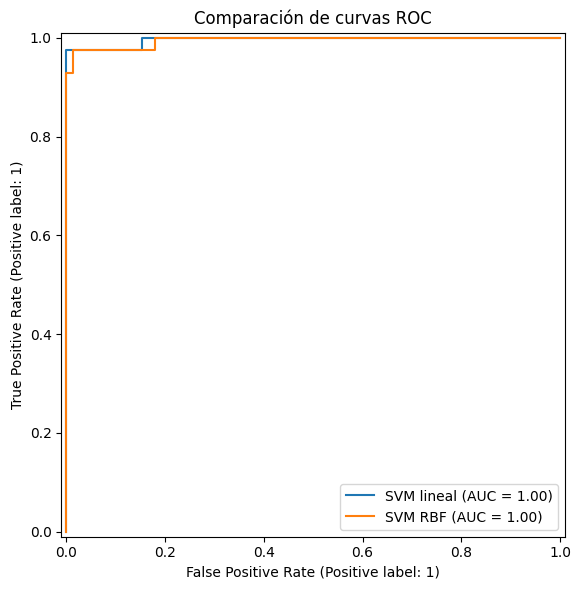

In [52]:
# Crear una figura para comparar las curvas ROC.
fig, ax = plt.subplots(figsize=(7, 6))
# Dibujar la curva ROC del modelo lineal.
RocCurveDisplay.from_predictions(
 y_test_maligno,
 prob_maligno_lineal,
 name="SVM lineal",
 ax=ax
)
# Dibujar la curva ROC del modelo RBF.
RocCurveDisplay.from_predictions(
 y_test_maligno,
 prob_maligno_rbf,
 name="SVM RBF",
 ax=ax
)
# Agregar el título de la figura.
ax.set_title("Comparación de curvas ROC")
# Ajustar el diseño.
plt.tight_layout()
# Mostrar la figura.
plt.show()

# **Actividad adicional: estudiar el efecto de los parámetros C y gamma mediante validación cruzada.**

# Una vez construidos los modelos iniciales, se requiere estudiar cómo influyen los hiperparámetros en el
desempeño. El objetivo será comparar varias configuraciones de SVM RBF sin utilizar el conjunto de prueba
para seleccionar el modelo.
Desarrolle las siguientes actividades:
1. Defina varios valores de C, por ejemplo, 0.1, 1 y 10.
2. Defina varios valores de gamma, por ejemplo, "scale", 0.01 y 0.1.
3. Utilice validación cruzada estratificada de cinco particiones sobre los datos de entrenamiento.
4. Seleccione la configuración mediante el F1-score de la clase maligna.
5. Evalúe una sola vez la configuración seleccionada con el conjunto de prueba reservado.
6. Compare las métricas del modelo optimizado con las del modelo RBF inicial.
7. Explique por qué una mejora en validación cruzada no garantiza el mismo desempeño en cualquier
población.

In [53]:
# Importar la herramienta de búsqueda de hiperparámetros.
from sklearn.model_selection import GridSearchCV

In [54]:
# Importar validación cruzada estratificada.
from sklearn.model_selection import StratifiedKFold

In [55]:
# Definir un pipeline que estandariza y después entrena SVM RBF.
pipeline_reto = Pipeline([
 # Estandarizar las características en cada partición de entrenamiento.
 ("escalado", StandardScaler()),
 # Crear el clasificador con kernel RBF.
 ("clasificador", SVC(kernel="rbf"))
])

In [56]:
# Definir las combinaciones de hiperparámetros que se probarán.
parametros = {
 "clasificador__C": [0.1, 1, 10],
 "clasificador__gamma": ["scale", 0.01, 0.1]
}

In [57]:
# Crear cinco particiones estratificadas para validación cruzada.
validacion = StratifiedKFold(
 n_splits=5,
 shuffle=True,
 random_state=42
)

In [58]:
# Configurar la búsqueda de hiperparámetros.
# El F1 se calcula para la clase positiva definida como 0 (maligno).
busqueda = GridSearchCV(
 estimator=pipeline_reto,
 param_grid=parametros,
 scoring="f1",
 cv=validacion,
 refit=True,
 n_jobs=-1
)

In [60]:
# Entrenar y comparar las configuraciones usando solo entrenamiento.
busqueda.fit(X_train, (y_train == 0).astype(int))
# Mostrar la combinación que obtuvo el mejor F1 promedio.
print("Mejores hiperparámetros:")
print(busqueda.best_params_)
# Mostrar el F1 promedio de validación cruzada.
print("Mejor F1 de validación cruzada:")
print(round(busqueda.best_score_, 4))
# Obtener el mejor pipeline ya ajustado por GridSearchCV.
mejor_modelo = busqueda.best_estimator_
# Convertir las predicciones binarias a las etiquetas originales.
# La búsqueda se entrenó con 1 = maligno y 0 = benigno.
pred_reto_binario = mejor_modelo.predict(X_test)
# Transformar 1 a la etiqueta original 0 (maligno)
# y 0 a la etiqueta original 1 (benigno).
pred_reto = np.where(pred_reto_binario == 1, 0, 1)
# Calcular la sensibilidad para la clase maligna.
sensibilidad_reto = recall_score(
 y_test,
 pred_reto,
 pos_label=0,
 zero_division=0
)
# Calcular la precisión para la clase maligna.
precision_reto = precision_score(
 y_test,
 pred_reto,
 pos_label=0,
 zero_division=0
)
# Calcular el F1-score para la clase maligna.
f1_reto = f1_score(
 y_test,
 pred_reto,
 pos_label=0,
 zero_division=0
)
# Calcular la exactitud general.
accuracy_reto = accuracy_score(y_test, pred_reto)
# Mostrar las métricas finales del modelo optimizado.
print(f"Accuracy: {accuracy_reto:.4f}")
print(f"Precisión para maligno: {precision_reto:.4f}")
print(f"Sensibilidad para maligno: {sensibilidad_reto:.4f}")
print(f"F1-score para maligno: {f1_reto:.4f}")

Mejores hiperparámetros:
{'clasificador__C': 10, 'clasificador__gamma': 0.01}
Mejor F1 de validación cruzada:
0.9668
Accuracy: 0.9825
Precisión para maligno: 0.9762
Sensibilidad para maligno: 0.9762
F1-score para maligno: 0.9762
